# Wilson loop and Green's function formalism

The Berry curvature along a k-path can be computed with two independent algorithms:
`mode="Wilson"` (a lattice gauge-invariant product of overlaps between neighboring occupied-band
projectors) and `mode="Green"` (a Green's-function/Kubo-type formula built from
$\partial_k H$). `topology.write_berry` scans a k-path with either method -- the two should
agree wherever both are numerically well-converged, giving an independent cross-check of the same
underlying Berry curvature.

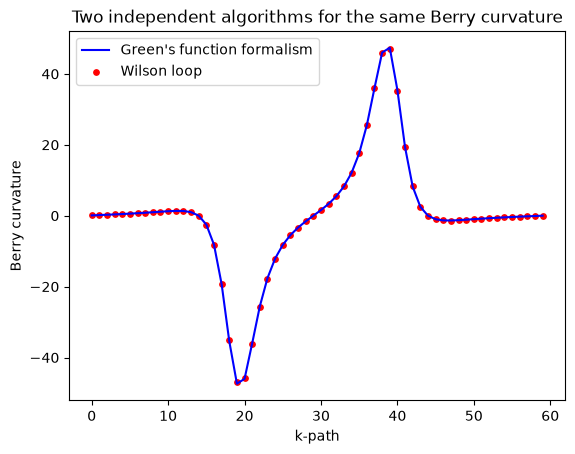

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology

g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
h.add_sublattice_imbalance(0.6)

(x1,y1) = topology.write_berry(h,mode="Wilson",nk=60)
(x,y) = topology.write_berry(h,mode="Green",nk=60)

plt.plot(x,y,c="blue",label="Green's function formalism")
plt.scatter(x1,y1,c="red",s=15,label="Wilson loop")
plt.xlabel("k-path") ; plt.ylabel("Berry curvature")
plt.legend()
plt.title("Two independent algorithms for the same Berry curvature")
plt.show()